# Notebook 01.3 — Aquisição e Caracterização da Oferta (UBS + capacidade CNES)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva | **Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs
**Última atualização:** 2026-06-15

---
## Objetivo
Adquirir a camada de **oferta de saúde** do modelo AE2SFCA — as UBS da zona urbana de
Teresina — e quantificar sua **capacidade** (`S_j`) a partir da Base de Dados CNES
(DataSUS), de forma **automatizada e reprodutível**. Caracteriza-se a oferta por análise
estatística e cartográfica.

## Entrada
| Arquivo | Origem |
|---|---|
| `externos/pmt/ubs_zonaUrbana.geojson` | SEMPLAN (localização das UBS, com código CNES) |
| Base de Dados CNES `BASE_DE_DADOS_CNES_AAAAMM.ZIP` | DataSUS (download automatizado) |

## Saída
| Arquivo | Consumido por |
|---|---|
| `intermediarios/03_ubs/teresina_ubs_capacidade_utm.parquet` | NB 05 (oferta `S_j`) |

## Pré-requisitos
- Conexão de internet no primeiro download (~700 MB, em cache depois).
- NB 01.1 executado (limites territoriais para os mapas).
---

In [1]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings, urllib.request, shutil, zipfile
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from mapeprof.config import (EXT_PMT, EXT_CNES, EXT_IBGE, INT_UBS,
                             FIGURAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import aplicar_estilo, barra_escala, seta_norte, moldura_mapa

aplicar_estilo(); warnings.filterwarnings("ignore"); criar_diretorios()
FIGURAS_NB = FIGURAS / "nb013"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Aquisição automatizada da Base CNES (DataSUS)

A capacidade das UBS é obtida da Base de Dados CNES, baixada **diretamente do servidor do
DataSUS** pela competência (AAAAMM), fixada para reprodutibilidade. A função é
*idempotente*: só baixa se o arquivo ainda não existir localmente.

In [2]:
# ── 2. DOWNLOAD AUTOMATIZADO DA BASE CNES ───────────────────────────────────
def baixar_base_cnes(competencia: str, destino=EXT_CNES):
    """Baixa a Base de Dados CNES do DataSUS para a competência AAAAMM (idempotente)."""
    arquivo = destino / f"BASE_DE_DADOS_CNES_{competencia}.ZIP"
    if arquivo.exists():
        print(f"✅ Base CNES {competencia} já presente: {arquivo.name}")
        return arquivo
    url = (f"https://cnes.datasus.gov.br/EstatisticasServlet?"
           f"path=BASE_DE_DADOS_CNES_{competencia}.ZIP")
    destino.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    print(f"⬇️ Baixando CNES {competencia} (~700 MB, pode levar minutos)...")
    with urllib.request.urlopen(req, timeout=300) as resp, open(arquivo, "wb") as f:
        shutil.copyfileobj(resp, f)
    print(f"✅ Salvo: {arquivo}")
    return arquivo

COMPETENCIA_CNES = "202604"   # fixa a competência (reprodutibilidade)
zip_cnes = baixar_base_cnes(COMPETENCIA_CNES)

✅ Base CNES 202604 já presente: BASE_DE_DADOS_CNES_202604.ZIP


## 3. Capacidade da oferta: equipes de Atenção Primária

A capacidade de cada UBS (`S_j`) é definida como o **número de equipes de Atenção Primária
ativas** — equipes de Saúde da Família (eSF, `TP_EQUIPE`=71) e equipes de Atenção Primária
(eAP, `TP_EQUIPE`=70) —, unidade de capacidade da APS segundo a PNAB. O código CNES (7
dígitos) corresponde aos últimos 7 dígitos de `CO_UNIDADE` na tabela de equipes.

In [3]:
# ── 3. CAPACIDADE (S_j) E JUNÇÃO COM AS UBS ─────────────────────────────────
COD_MUNICIPIO_TERESINA = "221100"
TIPOS_EQUIPE_APS = {"70", "71"}   # 70=eAP | 71=eSF

with zipfile.ZipFile(zip_cnes) as z:
    equipes = pd.read_csv(z.open(f"tbEquipe{COMPETENCIA_CNES}.csv"),
                          sep=";", encoding="latin-1", dtype=str)

ativas = equipes[(equipes["CO_MUNICIPIO"] == COD_MUNICIPIO_TERESINA)
                 & (equipes["DT_DESATIVACAO"].isna())
                 & (equipes["TP_EQUIPE"].isin(TIPOS_EQUIPE_APS))].copy()
ativas["cnes"] = ativas["CO_UNIDADE"].str[-7:]

capacidade = ativas.groupby("cnes").size().rename("capacidade_equipes")
n_esf = ativas[ativas["TP_EQUIPE"] == "71"].groupby("cnes").size()
n_eap = ativas[ativas["TP_EQUIPE"] == "70"].groupby("cnes").size()

ubs = gpd.read_file(EXT_PMT / "ubs_zonaUrbana.geojson").to_crs(CRS_METRICO)
ubs["capacidade_equipes"] = ubs["cnes"].astype(str).map(capacidade).fillna(0).astype(int)
ubs["n_esf"] = ubs["cnes"].astype(str).map(n_esf).fillna(0).astype(int)
ubs["n_eap"] = ubs["cnes"].astype(str).map(n_eap).fillna(0).astype(int)

saida = INT_UBS / "teresina_ubs_capacidade_utm.parquet"
ubs.to_parquet(saida)
print(f"💾 {len(ubs)} UBS | total {ubs['capacidade_equipes'].sum()} equipes de APS")
print(f"   UBS sem equipe registrada: {int((ubs['capacidade_equipes']==0).sum())}")
print(f"💾 Salvo: {saida}")

💾 75 UBS | total 459 equipes de APS
   UBS sem equipe registrada: 1
💾 Salvo: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\03_ubs\teresina_ubs_capacidade_utm.parquet


## 4. Análise exploratória da oferta

Caracterização estatística e cartográfica da capacidade instalada, base para a
interpretação dos resultados de acessibilidade (NB 05).

In [4]:
# ── 4.1 SÍNTESE ESTATÍSTICA ─────────────────────────────────────────────────
print("--- Capacidade (equipes de APS por UBS) ---")
print(ubs["capacidade_equipes"].describe().round(1).to_string())
print("\n--- Composição por tipo de equipe ---")
print(f"eSF (71): {ubs['n_esf'].sum()} | eAP (70): {ubs['n_eap'].sum()}")
print("\n--- Capacidade por regional administrativa ---")
print(ubs.groupby("regional")["capacidade_equipes"].agg(
    n_ubs="size", equipes="sum", media="mean").round(1).to_string())

--- Capacidade (equipes de APS por UBS) ---
count    75.0
mean      6.1
std       2.6
min       0.0
25%       4.0
50%       6.0
75%       8.0
max      12.0

--- Composição por tipo de equipe ---
eSF (71): 219 | eAP (70): 240

--- Capacidade por regional administrativa ---
          n_ubs  equipes  media
regional                       
LESTE        15       89    5.9
NORTE        20      137    6.8
SUDESTE      13       79    6.1
SUL          27      154    5.7


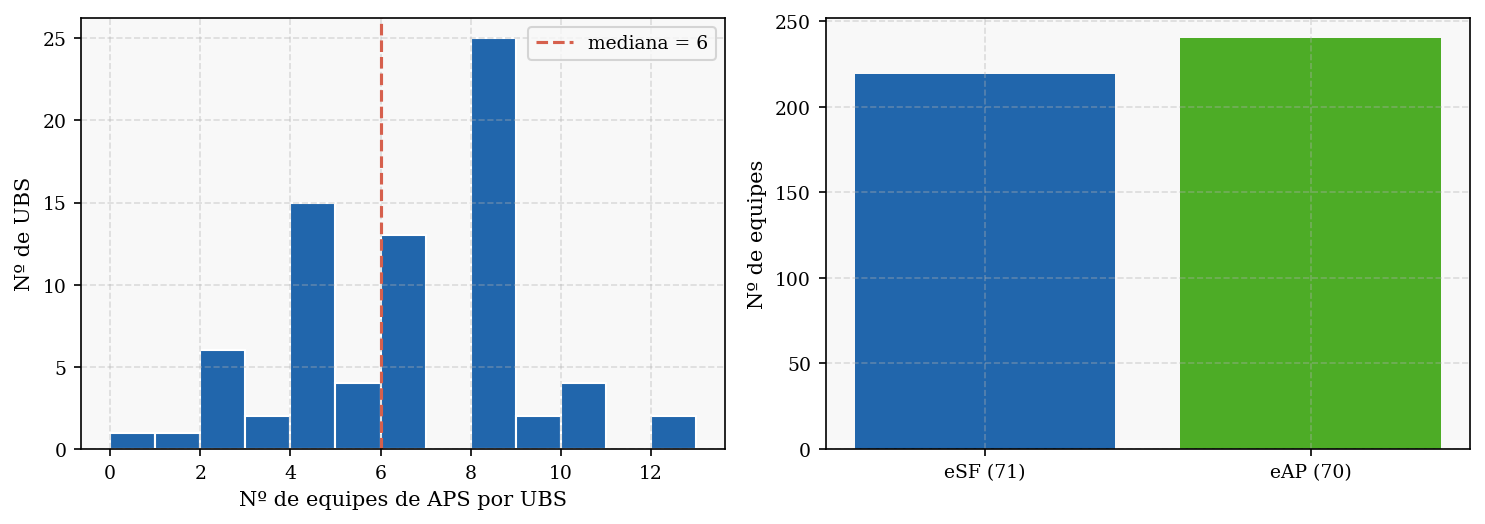

In [5]:
# ── Fig. 01 — Distribuição da capacidade e composição das equipes ───────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.hist(ubs["capacidade_equipes"], bins=range(0, 14), color="#2166AC", edgecolor="white")
a1.axvline(ubs["capacidade_equipes"].median(), ls="--", color="#D6604D",
           label=f"mediana = {ubs['capacidade_equipes'].median():.0f}")
a1.set_xlabel("Nº de equipes de APS por UBS"); a1.set_ylabel("Nº de UBS"); a1.legend()
a2.bar(["eSF (71)", "eAP (70)"], [ubs["n_esf"].sum(), ubs["n_eap"].sum()],
       color=["#2166AC", "#4DAC26"])
a2.set_ylabel("Nº de equipes")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb013_fig01_capacidade_distribuicao.png", bbox_inches="tight")
plt.show()

## 4.2 Distribuição espacial da oferta

Mapas que espacializam a capacidade (símbolos proporcionais), categorizam-na
qualitativamente (classes de capacidade) e a relacionam à divisão administrativa
(regionais de saúde).

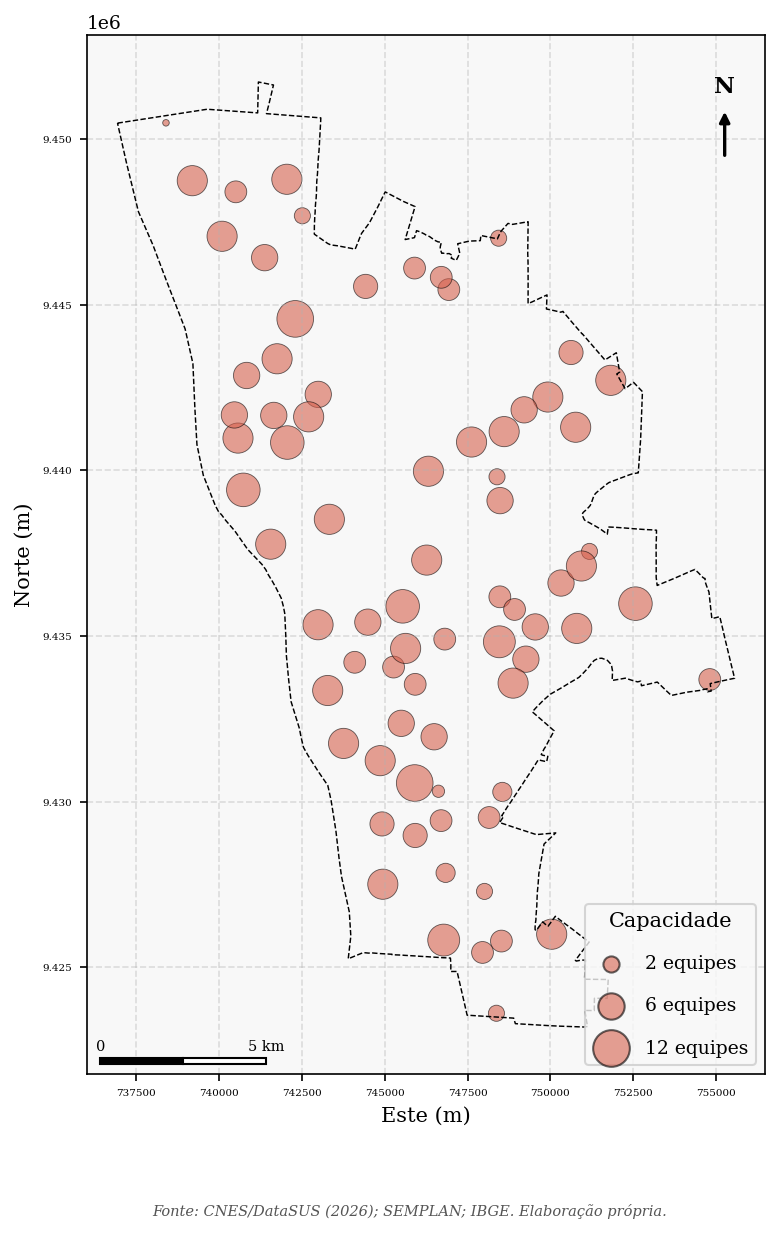

In [6]:
# ── Fig. 02 — Capacidade das UBS (símbolos proporcionais) ───────────────────
zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
fig, ax = plt.subplots(figsize=(9, 9))
zona_urbana.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=0.7)
ubs.plot(ax=ax, markersize=ubs["capacidade_equipes"] * 25 + 10,
         color="#D6604D", alpha=0.6, edgecolor="black", linewidth=0.4)
# legenda de tamanho
for n in (2, 6, 12):
    ax.scatter([], [], s=n*25+10, color="#D6604D", alpha=0.6, edgecolor="black",
               label=f"{n} equipes")
ax.legend(title="Capacidade", loc="lower right", labelspacing=1.3)
moldura_mapa(ax, "", "CNES/DataSUS (2026); SEMPLAN; IBGE. Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb013_fig02_mapa_capacidade.png", bbox_inches="tight")
plt.show()

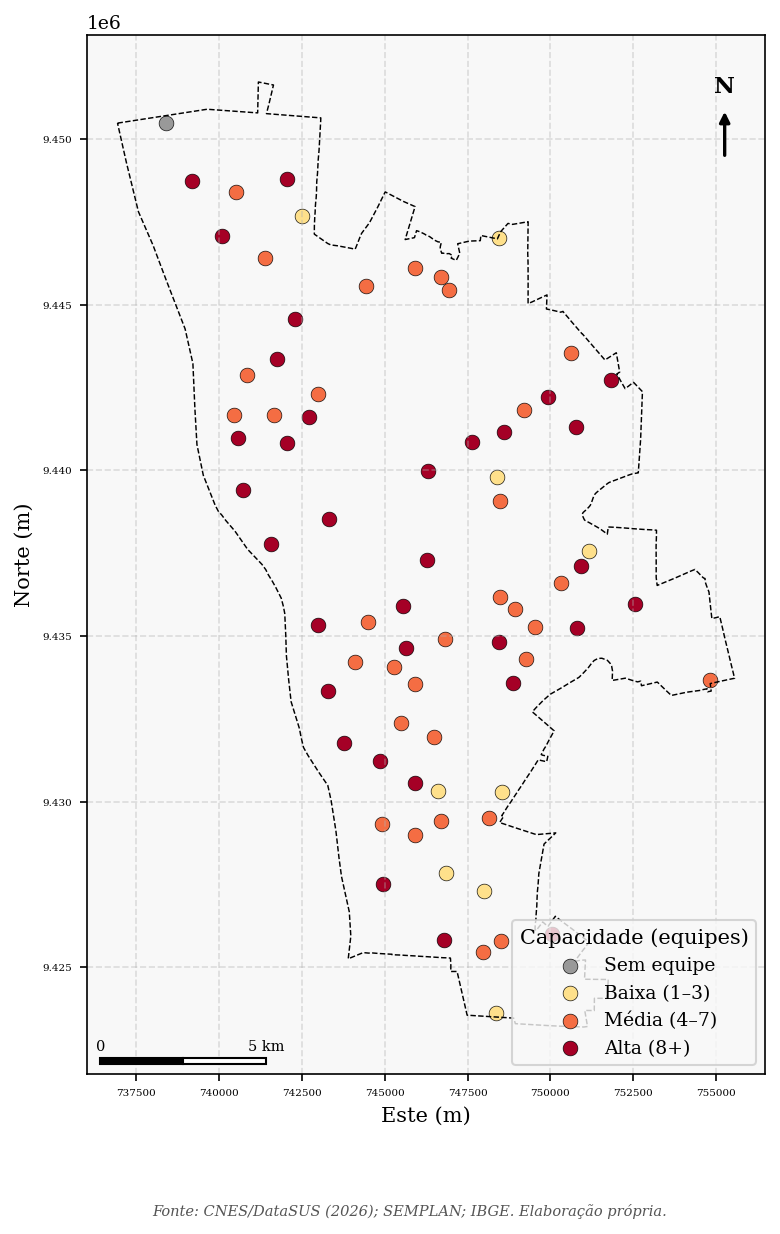

In [7]:
# ── Fig. 03 — Classes de capacidade (categorização qualitativa) ─────────────
ubs["classe_cap"] = pd.cut(ubs["capacidade_equipes"], bins=[-0.1, 0, 3, 7, 99],
                           labels=["Sem equipe", "Baixa (1–3)", "Média (4–7)", "Alta (8+)"])
CORES_CLASSE = {"Sem equipe": "#999999", "Baixa (1–3)": "#FEE08B",
                "Média (4–7)": "#F46D43", "Alta (8+)": "#A50026"}
fig, ax = plt.subplots(figsize=(9, 9))
zona_urbana.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=0.7)
for classe, cor in CORES_CLASSE.items():
    sub = ubs[ubs["classe_cap"] == classe]
    if len(sub):
        sub.plot(ax=ax, color=cor, markersize=50, edgecolor="black", linewidth=0.3, label=classe)
ax.legend(title="Capacidade (equipes)", loc="lower right")
moldura_mapa(ax, "", "CNES/DataSUS (2026); SEMPLAN; IBGE. Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb013_fig03_mapa_classes.png", bbox_inches="tight")
plt.show()

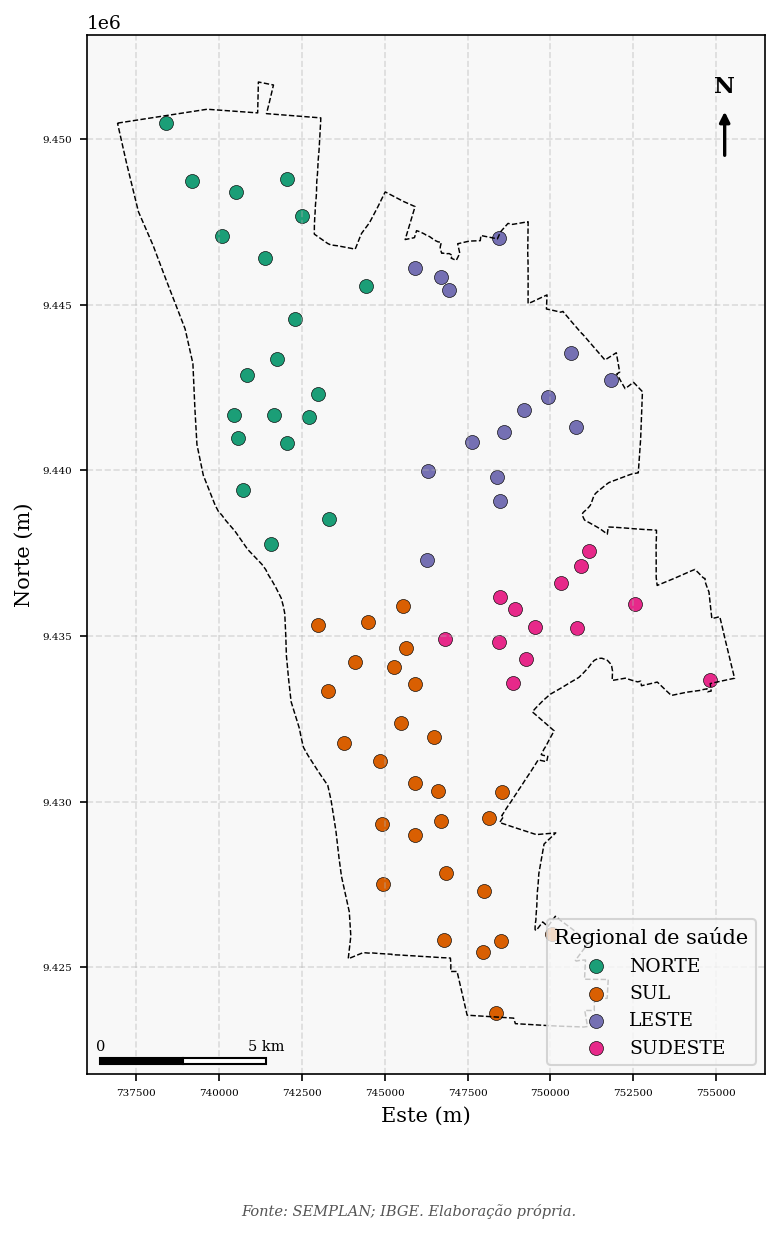

In [8]:
# ── Fig. 04 — UBS por regional administrativa (variável qualitativa) ────────
CORES_REGIONAL = {"NORTE": "#1B9E77", "SUL": "#D95F02", "LESTE": "#7570B3", "SUDESTE": "#E7298A"}
fig, ax = plt.subplots(figsize=(9, 9))
zona_urbana.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=0.7)
for reg, cor in CORES_REGIONAL.items():
    sub = ubs[ubs["regional"] == reg]
    if len(sub):
        sub.plot(ax=ax, color=cor, markersize=45, edgecolor="black", linewidth=0.3, label=reg)
ax.legend(title="Regional de saúde", loc="lower right")
moldura_mapa(ax, "", "SEMPLAN; IBGE. Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb013_fig04_mapa_regional.png", bbox_inches="tight")
plt.show()

---
## Próximos passos
A camada `teresina_ubs_capacidade_utm.parquet` fornece a oferta `S_j` (nº de equipes de
APS) ao **NB 05**, onde substitui a oferta provisória unitária no cálculo do AE2SFCA.